# M6.2 - NeMo Data Designer: AML SFT synthetic data (miniature)

A **miniature, fully self-contained** version of the production SFT synthetic-data
pipeline `gsi-training/4.sdg_sft/run-v3` (`SDG_STRATEGY_SFT.md`). It uses the
**exact same Data Designer SDK** and the same stage structure + prompts as
production -- on a tiny committed input set and a **single-GPU teacher NIM**
(Nemotron Nano 9B), so it finishes in minutes on one **A100 / H100 / H200** with
no hosted-API rate limit.

**What we generate (two tracks, like production):**

| Track | Records | What |
|-------|---------|------|
| A - `sar_judgment` (non-auxiliary) | ~48 cases | given an evidence bundle -> `{is_suspicious, suspicious_activity_report}` |
| B - auxiliary skills | ~6 | `numeric` / `citation` / `statutory` typed findings |

**Teacher model.** Production uses Gemma-4-31B on a 4x vLLM cluster. The workshop
uses the pre-built **Nemotron Nano 9B NIM** served locally on one GPU -- no
hosted-API rate limit, faster per call, and reasoning turned OFF for clean JSON.
Same Data Designer code path; only the endpoint/model differ.

**The non-auxiliary stages (identical to `main.py`):**
`1 drivers -> 2 KYC -> 3 transactions -> 4 sanctions -> 5 grounding ->
6 aux findings -> 7 SAR judgment (both classes) -> 9 validate + assemble`.

**Two hard rules (SDG_STRATEGY S2.1):**
- **No label leakage** - the SAR user message has exactly 7 keys; nothing tells
  the model the verdict/typology/frame.
- **Both classes grounded** - every record (positive *and* negative) has a
  400-800 char narrative; negatives are *disposition rationales*, not blanks.


## 1. Prerequisites (inline)

Installs the Data Designer SDK, checks the GPU, and starts the teacher NIM via
`docker` (prompts for your **NGC API key**). The NIM serves an OpenAI-compatible
endpoint on `:8000` that Data Designer points at -- no hosted-API rate limit.

In [1]:
import sys
from pathlib import Path

# Workshop shared helpers (parent folder: workshop-Materials/).
sys.path.insert(0, str(Path.cwd().parent))
from docker_storage import ensure_docker_storage
from notebook_env import bootstrap_notebook_env, ensure

ensure_docker_storage()  # docker images/layers on /data — avoids root disk full errors
bootstrap_notebook_env()

# data-designer is the real NVIDIA synthetic-data SDK (public PyPI). Pin to the
# production version. openai/pandas/requests are light supporting deps.
ensure("data_designer", ["data-designer==0.5.9"], quiet=True)
ensure("openai", ["openai>=1.40.0"], quiet=True)
ensure("pandas", ["pandas>=2.2.0"], quiet=True)
ensure("requests", ["requests>=2.32.0"], quiet=True)
print("\nPrerequisites ready.")


notebook env: /home/ubuntu/repo-content_copy/workshop-Materials/M6-data_designer/.venv (python /home/ubuntu/repo-content_copy/workshop-Materials/M6-data_designer/.venv/bin/python)
installing: data_designer ...
installing: openai ...
ok: pandas
ok: requests

Prerequisites ready.


In [2]:
import torch

# We host the 9B teacher locally on this GPU (no hosted-API rate limit). The NIM
# needs one A100 / H100 / H200.
assert torch.cuda.is_available(), "A CUDA GPU is required to serve the teacher NIM locally."
_p = torch.cuda.get_device_properties(0)
print(f"GPU: {_p.name} ({_p.total_memory / 2**30:.1f} GiB) | CUDA {torch.version.cuda}")


GPU: NVIDIA A100 80GB PCIe (79.3 GiB) | CUDA 12.8


In [3]:
import os, subprocess, time, getpass, socket
from pathlib import Path
import requests

# --- NGC API key (runtime prompt; not stored in the notebook) ---
if not os.environ.get("NGC_API_KEY"):
    _k = getpass.getpass("Enter your NGC API key: ").strip()
    if _k:
        os.environ["NGC_API_KEY"] = _k
if not os.environ.get("NGC_API_KEY"):
    raise ValueError("NGC_API_KEY is required to pull/run the NIM from nvcr.io")

LOCAL_NIM_CACHE = Path(os.environ.get("LOCAL_NIM_CACHE", Path.home() / ".cache" / "nim"))
LOCAL_NIM_CACHE.mkdir(parents=True, exist_ok=True)
NIM_IMAGE = "nvcr.io/nim/nvidia/nvidia-nemotron-nano-9b-v2:latest"
NIM_CONTAINER = "workshop-nim-nano"
LLM_MODEL = "nvidia/nvidia-nemotron-nano-9b-v2"

# Host port: 8000 is often already taken on shared boxes ("address already in
# use"), so pick the first candidate that is either already serving our NIM
# (reuse it) or free to bind.
CANDIDATE_PORTS = [8000, 8001, 8002, 8083, 8085, 9001]

def _nim_on(port):
    try:
        return requests.get(f"http://localhost:{port}/v1/models", timeout=3).status_code == 200
    except Exception:
        return False

def _port_free(port):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        try:
            s.bind(("0.0.0.0", port)); return True
        except OSError:
            return False

NIM_PORT = next((p for p in CANDIDATE_PORTS if _nim_on(p)), None)
if NIM_PORT is not None:
    print(f"Reusing a NIM already serving on :{NIM_PORT}")
else:
    NIM_PORT = next((p for p in CANDIDATE_PORTS if _port_free(p)), None)
    if NIM_PORT is None:
        raise RuntimeError(f"No free host port among {CANDIDATE_PORTS}; free one and re-run.")
    print("Docker login -> nvcr.io ...")
    subprocess.run(["docker", "login", "nvcr.io", "-u", "$oauthtoken", "--password-stdin"],
                   input=os.environ["NGC_API_KEY"].encode(), check=True)
    subprocess.run(["docker", "rm", "-f", NIM_CONTAINER], capture_output=True)
    print("Pulling NIM image (first time: several minutes) ...")
    subprocess.check_call(["docker", "pull", NIM_IMAGE])
    print(f"Starting NIM container on host port {NIM_PORT} ...")
    subprocess.check_call([
        "docker", "run", "-d", "--name", NIM_CONTAINER,
        # Pin to a SINGLE GPU (device 0). Nemotron Nano 9B fits on one
        # A100/H100/H200; do NOT use `--gpus all` on a multi-GPU box.
        "--gpus", "device=0", "--shm-size", "16GB",
        "-e", "NGC_API_KEY",
        "-v", f"{LOCAL_NIM_CACHE}:/opt/nim/.cache",
        "-u", str(os.getuid()),
        "-p", f"{NIM_PORT}:8000", NIM_IMAGE,
    ], env=os.environ.copy())
    for _i in range(80):
        if _nim_on(NIM_PORT):
            break
        print(f"  waiting for NIM model load ... ({_i + 1}/80)")
        time.sleep(15)
    else:
        raise RuntimeError("NIM not ready - check: docker logs workshop-nim-nano")

LLM_URL = f"http://localhost:{NIM_PORT}/v1"
LLM_API_KEY = "dummy"   # local NIM ignores the api key
print("Teacher endpoint:", LLM_URL, "| model:", LLM_MODEL)


Enter your NGC API key:  ········


Docker login -> nvcr.io ...


WARNING! Your password will be stored unencrypted in /home/ubuntu/.docker/config.json.
Configure a credential helper to remove this warning. See
https://docs.docker.com/engine/reference/commandline/login/#credential-stores



Login Succeeded
Pulling NIM image (first time: several minutes) ...
latest: Pulling from nim/nvidia/nvidia-nemotron-nano-9b-v2
65d6848aa6be: Pulling fs layer
ddc9da18b513: Pulling fs layer
4a39b63a208f: Pulling fs layer
8378c496babf: Pulling fs layer
ed0e2082d1bb: Pulling fs layer
b61659d9f609: Pulling fs layer
efaeba21701f: Pulling fs layer
d0ef6a820a7a: Pulling fs layer
b53078d42f1b: Pulling fs layer
9188cf7c8d41: Pulling fs layer
0154c8c7b419: Pulling fs layer
09693755eb54: Pulling fs layer
53afbb9356e9: Pulling fs layer
adedb551814d: Pulling fs layer
d502bdcaf3c6: Pulling fs layer
a0bda0fbe791: Pulling fs layer
36958f672d5a: Pulling fs layer
d5f8005d7dbc: Pulling fs layer
d95e964e9e83: Pulling fs layer
9671628a37fb: Pulling fs layer
a54a593b2866: Pulling fs layer
312f91995407: Pulling fs layer
b400957fb4c3: Pulling fs layer
161b59c42a08: Pulling fs layer
26738a387089: Pulling fs layer
b6504d77d244: Pulling fs layer
4f4fb700ef54: Pulling fs layer
a7ff4ac4e988: Pulling fs layer
b72ef

## 2. Data Designer client + a reusable LLM-column helper

We wire Data Designer to the local NIM (an OpenAI-compatible `ModelProvider`) and
define `run_llm_column(...)` -- a one-shot Data Designer pass for a single LLM
column. This is the miniature of production's `common/dd_helpers.run_dd_pass`:
write the seed rows to CSV, add one `LLMTextColumnConfig`, `create(...)`, and
return the seed joined with the generated column. `enable_thinking=False` keeps
the model from emitting a slow `<think>` trace.

In [4]:
import json, csv, re
from pathlib import Path
import pandas as pd

import data_designer.config as dd
from data_designer.config.models import (
    ChatCompletionInferenceParams, ModelConfig, ModelProvider,
)
from data_designer.interface import DataDesigner

NB_DIR = Path.cwd().resolve()
INPUT = NB_DIR / "data" / "input"
WORK = NB_DIR / "work"; WORK.mkdir(parents=True, exist_ok=True)
FINAL = NB_DIR / "data" / "final"; FINAL.mkdir(parents=True, exist_ok=True)
ARTIFACTS = WORK / "dd_artifacts"

MODEL_ALIAS = "sft-generator"
PROVIDER_NAME = "local-nim"

def _provider():
    # OpenAI-compatible local NIM provider (api_key is ignored by a local NIM).
    return ModelProvider(name=PROVIDER_NAME, endpoint=LLM_URL,
                         provider_type="openai", api_key=LLM_API_KEY)

def _model_config(temperature=0.7, max_tokens=2048, max_parallel=8, timeout=300):
    # One model config per pass. `enable_thinking=False` (via extra_body) turns
    # OFF the model's reasoning trace -> much faster, clean-JSON output. The local
    # NIM has no rate limit, so max_parallel can be larger (the NIM batches
    # internally); raise it for more throughput on a bigger GPU.
    return ModelConfig(
        alias=MODEL_ALIAS, model=LLM_MODEL, provider=PROVIDER_NAME,
        # skip_health_check: Data Designer's health probe sends a *system* message
        # whose content is a list, which this NIM rejects ("content as a list is
        # only supported for user messages"). We skip it and send our own
        # user-only prompts below.
        skip_health_check=True,
        inference_parameters=ChatCompletionInferenceParams(
            temperature=temperature, top_p=0.95, max_tokens=max_tokens,
            timeout=timeout, max_parallel_requests=max_parallel,
            extra_body={"chat_template_kwargs": {"enable_thinking": False}}),
    )

def run_llm_column(seed_df, *, system_prompt, user_template, output_column,
                   dataset_name, temperature=0.7, max_tokens=2048, max_parallel=8):
    """One Data Designer pass that adds a single LLM-generated column to seed_df.

    The user_template is Jinja - {{ col }} refers to a seed column. Returns the
    seed dataframe with `output_column` appended (row order preserved).
    """
    if len(seed_df) == 0:
        return seed_df.copy()
    art = ARTIFACTS / dataset_name
    art.mkdir(parents=True, exist_ok=True)
    # DataDesigner reads the seed via DuckDB strict-mode: quote all fields and
    # strip embedded newlines so free-text values don't break row parsing.
    clean = seed_df.copy()
    for c in clean.columns:
        if clean[c].dtype == object:
            clean[c] = clean[c].astype(str).str.replace(r"[\r\n]+", " ", regex=True)
    seed_csv = art / "seed.csv"
    clean.to_csv(seed_csv, index=False, quoting=csv.QUOTE_ALL)

    cb = dd.DataDesignerConfigBuilder(model_configs=[
        _model_config(temperature=temperature, max_tokens=max_tokens, max_parallel=max_parallel)])
    cb.with_seed_dataset(dd.LocalFileSeedSource(path=str(seed_csv)))
    # This NIM accepts list-form message content only for USER messages (not
    # system). Data Designer sends a separate system message as a list, which the
    # NIM rejects -- so we fold the system instructions into the user prompt and
    # send no separate system message. (The final SFT records still carry a
    # proper system message; that's assembled later, not via this generation call.)
    # `/no_think` is Nemotron Nano 2's directive to disable its reasoning trace.
    # (This NIM ignores the OpenAI `enable_thinking` flag; the directive is the
    # control that actually works.) We prepend it to the user prompt since we
    # cannot send a separate system message to this NIM.
    combined_prompt = (system_prompt.strip() + "\n\n----\n\n" + user_template) if system_prompt else user_template
    combined_prompt = "/no_think\n\n" + combined_prompt
    cb.add_column(dd.LLMTextColumnConfig(
        name=output_column, model_alias=MODEL_ALIAS, prompt=combined_prompt))

    runtime = DataDesigner(artifact_path=str(art), model_providers=[_provider()])
    result = runtime.create(cb, num_records=len(seed_df), dataset_name=dataset_name)
    out = result.load_dataset()
    if not isinstance(out, pd.DataFrame):
        out = pd.DataFrame(out)
    # Re-attach generated column to the ORIGINAL (un-stripped) seed by position.
    joined = seed_df.reset_index(drop=True).copy()
    joined[output_column] = out[output_column].reset_index(drop=True)
    return joined

def safe_json(s):
    """Parse JSON out of a model response. Robust to (a) a leading <think>...</think>
    reasoning trace, (b) ```json fences, and (c) prose around the JSON: as a
    fallback it grabs the last {...} or [...] block. Returns None on failure."""
    s = (s or "").strip()
    # 1) drop any reasoning trace if the model still emitted one
    s = re.sub(r"<think>.*?</think>", "", s, flags=re.DOTALL).strip()
    # 2) strip a leading code fence
    for f in ("```json", "```JSON", "```"):
        if s.startswith(f):
            s = s[len(f):].strip()
            if s.endswith("```"):
                s = s[:-3].strip()
            break
    try:
        return json.loads(s)
    except Exception:
        pass
    # 3) fallback: last balanced object/array in the text
    m = re.findall(r"(\{.*\}|\[.*\])", s, flags=re.DOTALL)
    if m:
        try:
            return json.loads(m[-1])
        except Exception:
            return None
    return None

print("Data Designer wired to", LLM_URL)


/home/ubuntu/repo-content_copy/workshop-Materials/M6-data_designer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data Designer wired to http://localhost:8000/v1


## 3. Stage 1 - Drivers

Each driver row is one SAR case to generate, carrying its *internal* typology /
regulatory frame / gold label / surface pattern. These fields steer generation
and let us check the model's verdict, but they are **never written into the SAR
user message** (no-leakage rule). Drivers ship in `data/input/sft/case_drivers.jsonl`
and are balanced ~45/55 positive/negative with a near-miss negative fraction --
the production distribution targets, scaled down.

In [5]:
drivers = pd.DataFrame(
    json.loads(l) for l in (INPUT / "sft" / "case_drivers.jsonl").read_text().splitlines() if l.strip()
)
print(f"{len(drivers)} cases | positives={int(drivers.is_suspicious_target.sum())} "
      f"({drivers.is_suspicious_target.mean():.0%})")
print(drivers.groupby(["typology", "is_suspicious_target"]).size().to_string())
drivers.head(3)


48 cases | positives=22 (46%)
typology             is_suspicious_target
elder_exploitation   False                    1
                     True                     2
human_trafficking    False                    1
                     True                     3
layering             False                    1
                     True                     3
none                 False                   17
shell_company        False                    1
                     True                     3
smurfing             False                    1
                     True                     3
structuring          False                    1
                     True                     3
terrorist_financing  False                    2
                     True                     2
trade_based_ml       False                    1
                     True                     3


,case_id,entity_id,entity_archetype,entity_type,typology,regulatory_frame,is_suspicious_target,severity,surface_pattern,incorporation_jurisdiction,expected_monthly_volume
0,CASE-0001,SYN_0001,cash_intensive_convenience,business,smurfing,ctr,True,heavy,active_pattern,US,6000
1,CASE-0006,SYN_0006,money_services_business,business,terrorist_financing,trafficking,True,heavy,active_pattern,US,6000
2,CASE-0035,SYN_0035,individual_wage_earner,individual,none,benign,False,light,clean,US,150000


## 4. Stage 2 - KYC profile

One LLM call generates the free-text `business_purpose` (verbatim production
`BUSINESS_PURPOSE_SYSTEM`); the structured KYC fields (`risk_rating`,
`expected_monthly_volume`, `incorporation_jurisdiction`, `entity_type`) are set
deterministically from the driver -- exactly the production split (deterministic
fields + one LLM field).

In [6]:
SYS_KYC = "You write the business_purpose field for a KYC profile in a financial institution's Customer Due Diligence record. The field is one sentence (15-50 words) describing what the entity does, declared revenue/volume markers, and any cash-receipt characteristics relevant to AML risk. Output ONLY the sentence -- no preamble, no quotes."
USR_KYC = 'Entity archetype: {{ entity_archetype }}\nEntity type:      {{ entity_type }}\nJurisdiction:     {{ incorporation_jurisdiction }}\nExpected monthly volume: ${{ expected_monthly_volume }}\nTypology hypothesis (for narrative consistency): {{ typology }}\n\nWrite the business_purpose sentence.'

kyc_seed = drivers[["case_id", "entity_archetype", "entity_type",
                    "incorporation_jurisdiction", "expected_monthly_volume", "typology"]].copy()
kyc_df = run_llm_column(kyc_seed, system_prompt=SYS_KYC, user_template=USR_KYC,
                        output_column="business_purpose", dataset_name="stage2_kyc",
                        temperature=0.6, max_tokens=200)

import random as _rnd
_rnd.seed(1)
def _risk(row):
    if row.is_suspicious_target: return _rnd.choice(["high", "high", "enhanced"])
    return _rnd.choice(["low", "low", "medium", "medium", "high"])

# Belt-and-suspenders: if the teacher still prepends a reasoning monologue to the
# free-text business_purpose, keep a clean one-liner -- strip any <think> trace,
# and if it still reads like reasoning, fall back to a deterministic CDD sentence.
_REASON_TELL = re.compile(r"\b(okay|let's|let us|the user needs|first,|i need to|we need to)\b", re.I)
def _clean_purpose(text, archetype, juris, vol):
    t = re.sub(r"<think>.*?</think>", "", str(text or ""), flags=re.DOTALL).strip().strip('"').strip()
    sents = re.split(r"(?<=[.!?])\s+", t)
    good = [s for s in sents if s and not _REASON_TELL.search(s) and 6 <= len(s.split()) <= 60]
    if good:
        return " ".join(good[:2])[:400]
    return (f"{archetype.replace('_', ' ').title()} in {juris} with declared expected "
            f"monthly volume of approximately ${int(vol):,}; cash-receipt activity monitored for AML risk.")

drivers = drivers.merge(kyc_df[["case_id", "business_purpose"]], on="case_id", how="left")
drivers["business_purpose"] = drivers.apply(
    lambda r: _clean_purpose(r.business_purpose, r.entity_archetype,
                             r.incorporation_jurisdiction, r.expected_monthly_volume), axis=1)
drivers["risk_rating"] = drivers.apply(_risk, axis=1)

def kyc_profile(r):
    return {"entity_id": r.entity_id, "entity_type": r.entity_type,
            "expected_monthly_volume": int(r.expected_monthly_volume),
            "business_purpose": str(r.business_purpose),
            "risk_rating": r.risk_rating,
            "incorporation_jurisdiction": r.incorporation_jurisdiction}
drivers["kyc_profile"] = drivers.apply(kyc_profile, axis=1)
print(json.dumps(drivers.iloc[0].kyc_profile, indent=2)[:500])


[15:41:54] [INFO] 🎨 Creating Data Designer dataset
[15:41:54] [INFO]   |-- 🔒 Jinja rendering engine: secure
[15:41:54] [INFO] ✅ Validation passed
[15:41:54] [INFO] ⛓️ Sorting column configs into a Directed Acyclic Graph
[15:41:54] [INFO] 🩺 Running health checks for models...
[15:41:54] [INFO]   |-- ⏭️  Skipping health check for model alias 'sft-generator' (skip_health_check=True)
[15:41:54] [INFO] ⏳ Processing batch 1 of 1
[15:41:54] [INFO] 🌱 Sampling 48 records from seed dataset
[15:41:54] [INFO]   |-- seed dataset size: 48 records
[15:41:54] [INFO]   |-- sampling strategy: ordered
[15:41:54] [INFO] 📝 llm-text model config for column 'business_purpose'
[15:41:54] [INFO]   |-- model: 'nvidia/nvidia-nemotron-nano-9b-v2'
[15:41:54] [INFO]   |-- model alias: 'sft-generator'
[15:41:54] [INFO]   |-- model provider: 'local-nim'
[15:41:54] [INFO]   |-- inference parameters:
[15:41:54] [INFO]   |  |-- generation_type=chat-completion
[15:41:54] [INFO]   |  |-- max_parallel_requests=8
[15:41:54]

{
  "entity_id": "SYN_0001",
  "entity_type": "business",
  "expected_monthly_volume": 6000,
  "business_purpose": "The business operates a cash-intensive convenience service in the US, processing approximately $6,000 in monthly volume with frequent small cash receipts, consistent with a smurfing typology that may indicate layered transaction patterns to evade detection.",
  "risk_rating": "high",
  "incorporation_jurisdiction": "US"
}


## 5. Stage 3 - Transactions (label-aware)

One LLM call per case generates the transaction set. The system prompt is the
production label-aware transaction generator: **benign** cases stay within
1.0-1.5x declared volume with dispersed channels; **suspicious** cases reflect
the typology (sub-CTR cash for structuring, rapid wires for layering, etc.). This
is what makes the two classes look different *in the evidence*, not in any label
field.

In [7]:
SYS_TX = 'You generate a realistic transaction set for a synthetic AML case used to\ntrain an investigation model. The user message tells you whether the case is\nSUSPICIOUS (is_suspicious=true) or BENIGN (is_suspicious=false); the transactions\nyou emit MUST reflect that label.\n\nOutput a JSON array where each element has EXACTLY these keys:\n{date, amount, currency, counterparty, channel, notes} with\nchannel in {wire, ach, cash, card, cheque, crypto}. Dates are ISO (YYYY-MM-DD)\nwithin a single investigation month. Severity -> count: light=3-6, medium=7-15,\nheavy=16-30.\n\nBENIGN MODE (is_suspicious=false):\n  * Total transaction value SHOULD be within 1.0x to 1.5x the declared monthly\n    volume -- NOT 5x, NOT 30x.\n  * Cash transactions, if any, each UNDER $5,000. Do NOT produce multiple\n    sub-$10K cash deposits across branches (that is structuring).\n  * Channels weighted toward ach/card; wire/crypto/large cash rare or absent.\n  * Pattern: ordinary, dispersed activity; do NOT cluster repeated identical\n    amounts.\n\nSUSPICIOUS MODE (is_suspicious=true):\n  * Reflect the typology in the pattern (structuring -> sub-CTR cash; smurfing ->\n    many small cash deposits across actors; layering -> rapid wire pass-through;\n    trade_based_ml -> over/under-invoiced wires; shell_company -> offshore wires;\n    elder_exploitation -> large wires to a new payee).\n  * Total may exceed declared volume by 3-6x depending on typology.\n\nOutput ONLY the JSON array -- no prose, no code fences.'
USR_TX = 'Case typology: {{ typology }}\nis_suspicious: {{ is_suspicious }}\nSeverity: {{ severity }}\nDeclared expected monthly volume: ${{ expected_monthly_volume }}\nKYC business purpose: {{ business_purpose }}\n\nGenerate the transaction JSON array (honor BENIGN vs SUSPICIOUS constraints).'

tx_seed = drivers[["case_id", "typology", "is_suspicious_target", "severity",
                   "expected_monthly_volume", "business_purpose"]].copy()
tx_seed = tx_seed.rename(columns={"is_suspicious_target": "is_suspicious"})
tx_df = run_llm_column(tx_seed, system_prompt=SYS_TX, user_template=USR_TX,
                       output_column="transactions_raw", dataset_name="stage3_tx",
                       temperature=0.5, max_tokens=3072)

def parse_tx(s):
    v = safe_json(s)
    return v if isinstance(v, list) else []
tx_df["transactions"] = tx_df["transactions_raw"].map(parse_tx)
drivers = drivers.merge(tx_df[["case_id", "transactions"]], on="case_id", how="left")
_n = drivers["transactions"].map(len)
print(f"transactions/case: min={_n.min()} median={int(_n.median())} max={_n.max()}")
print(json.dumps(drivers.iloc[0].transactions[:2], indent=2)[:600])


[15:42:11] [INFO] 🎨 Creating Data Designer dataset
[15:42:11] [INFO]   |-- 🔒 Jinja rendering engine: secure
[15:42:11] [INFO] ✅ Validation passed
[15:42:11] [INFO] ⛓️ Sorting column configs into a Directed Acyclic Graph
[15:42:11] [INFO] 🩺 Running health checks for models...
[15:42:11] [INFO]   |-- ⏭️  Skipping health check for model alias 'sft-generator' (skip_health_check=True)
[15:42:11] [INFO] ⏳ Processing batch 1 of 1
[15:42:11] [INFO] 🌱 Sampling 48 records from seed dataset
[15:42:11] [INFO]   |-- seed dataset size: 48 records
[15:42:11] [INFO]   |-- sampling strategy: ordered
[15:42:11] [INFO] 📝 llm-text model config for column 'transactions_raw'
[15:42:11] [INFO]   |-- model: 'nvidia/nvidia-nemotron-nano-9b-v2'
[15:42:11] [INFO]   |-- model alias: 'sft-generator'
[15:42:11] [INFO]   |-- model provider: 'local-nim'
[15:42:11] [INFO]   |-- inference parameters:
[15:42:11] [INFO]   |  |-- generation_type=chat-completion
[15:42:11] [INFO]   |  |-- max_parallel_requests=8
[15:42:11]

transactions/case: min=0 median=6 max=30
[
  {
    "date": "2023-10-01",
    "amount": 1200,
    "currency": "USD",
    "counterparty": "Merchant A",
    "channel": "cash",
    "notes": "Small cash deposit"
  },
  {
    "date": "2023-10-02",
    "amount": 1500,
    "currency": "USD",
    "counterparty": "Merchant B",
    "channel": "cash",
    "notes": "Small cash deposit"
  }
]


## 6. Stage 4 - Sanctions screening (deterministic)

No LLM here -- production fuzzy-matches transaction counterparties against the
OFAC/PEP watchlist (`rapidfuzz`, score >= 0.55). We use a light token-overlap
match against `data/input/transactional/sanctions_watchlist.jsonl`. Common-name
entries ("Michael Brown", "John Smith") generate **noise hits** -- the negatives
the model must learn to disposition.

In [8]:
watch = [json.loads(l) for l in (INPUT / "transactional" / "sanctions_watchlist.jsonl").read_text().splitlines() if l.strip()]

def _toks(s): return set(re.findall(r"[a-z0-9]+", str(s).lower()))
def screen(transactions):
    hits = []
    for tx in transactions:
        cp = tx.get("counterparty", "")
        ctoks = _toks(cp)
        if not ctoks: continue
        for w in watch:
            wt = _toks(w["name"])
            if not wt: continue
            overlap = len(ctoks & wt) / max(len(wt), 1)
            if overlap >= 0.5:
                score = 0.92 if w["kind"] == "common_name_noise" else 0.97
                hits.append({"name": w["name"], "list": w["list"], "match_score": score})
                break
    # de-dup by name
    seen, out = set(), []
    for h in hits:
        if h["name"] not in seen:
            seen.add(h["name"]); out.append(h)
    return out
drivers["sanctions_pep_hits"] = drivers["transactions"].map(screen)
print("cases with >=1 sanctions hit:", int((drivers.sanctions_pep_hits.map(len) > 0).sum()))


cases with >=1 sanctions hit: 1


## 7. Stage 5 - Grounding (policy + SOP excerpts)

Deterministic retrieval: attach typology-relevant policy excerpts (and a couple
of broad ones as a safety net) from `data/input/sft/policy_excerpts.jsonl`. These
become the `policy_excerpts` / `sop_excerpts` keys in the bundle and are the only
regulatory text the model is allowed to cite.

In [9]:
policy = [json.loads(l) for l in (INPUT / "sft" / "policy_excerpts.jsonl").read_text().splitlines() if l.strip()]
# crude typology -> excerpt keyword routing (production keys on the typology guess)
ROUTE = {
    "structuring": ["5324", "Structuring"], "smurfing": ["5324", "Structuring"],
    "layering": ["Layering"], "trade_based_ml": ["Trade-Based"],
    "elder_exploitation": ["Elder"], "shell_company": ["Layering"],
    "terrorist_financing": ["OFAC"], "human_trafficking": ["Elder"], "none": [],
}
def ground(typ):
    keys = ROUTE.get(typ, [])
    focused = [p for p in policy if any(k.lower() in (p["section"] + p["text"]).lower() for k in keys)][:3]
    broad = [p for p in policy if p not in focused][:2]   # safety-net broad excerpts
    return focused + broad
drivers["policy_excerpts"] = drivers["typology"].map(ground)
drivers["sop_excerpts"] = [[] for _ in range(len(drivers))]
print("example policy sections for case 0:",
      [p["section"] for p in drivers.iloc[0].policy_excerpts])


example policy sections for case 0: ['31 U.S.C. 5324', 'Structuring red flags', 'Trade-Based Money Laundering', 'FIN-2022-A002 Elder Financial Exploitation']


## 8. Stage 6 - Auxiliary findings (optional, per-case)

Production attaches pre-computed auxiliary findings to a subset of cases
(`augmented` variant) and a deliberately-wrong finding to an `adversarial_aux`
subset. For the miniature we keep `auxiliary_findings = null` on the SAR bundle
(the `bare` variant) and demonstrate the auxiliary skills standalone in **Track B**
below. (Set `AUX_ON_BUNDLE = True` to experiment with inline findings.)

In [10]:
AUX_ON_BUNDLE = False
drivers["auxiliary_findings"] = [None for _ in range(len(drivers))]
print("auxiliary_findings on bundle:", AUX_ON_BUNDLE, "(bare variant)")


auxiliary_findings on bundle: False (bare variant)


## 9. Stage 7 - SAR judgment (both classes)

The core stage. We build the **7-key bundle** (no leakage), attach 1-2 reference
narrative patterns (style only), and run the verbatim production
`SAR_PAIR_GROUND_SYSTEM`. The model derives `is_suspicious` from the evidence and
writes a 400-800 char grounded narrative for **both** classes.

In [11]:
refs = [json.loads(l) for l in (INPUT / "sft" / "reference_narratives.jsonl").read_text().splitlines() if l.strip()]
def patterns_for(typ):
    same = [r["notes"] for r in refs if r["typology"] == typ][:2]
    if not same:
        same = [r["notes"] for r in refs][:1]
    return "\n\n".join(f"- {p}" for p in same)

def bundle_json(r):
    # EXACTLY 7 keys - no _decision_target / _regulatory_frame / _typology_inferred.
    b = {"task_type": "sar_judgment", "transactions": r.transactions,
         "kyc_profile": r.kyc_profile, "sanctions_pep_hits": r.sanctions_pep_hits,
         "policy_excerpts": r.policy_excerpts, "sop_excerpts": r.sop_excerpts,
         "auxiliary_findings": r.auxiliary_findings}
    return json.dumps(b, ensure_ascii=False)

sar_seed = drivers[["case_id", "typology"]].copy()
sar_seed["bundle_json"] = drivers.apply(bundle_json, axis=1)
sar_seed["patterns_block"] = drivers["typology"].map(patterns_for)


In [12]:
SYS_SAR = 'You are a senior AML / BSA investigator at a financial institution.\nYou will receive a single JSON object in the user message containing exactly\nthe following seven keys:\n\n    {\n      "task_type":          "sar_judgment",\n      "transactions":       [<tx>, ...],\n      "kyc_profile":        {entity_id, entity_type, expected_monthly_volume,\n                             business_purpose, risk_rating,\n                             incorporation_jurisdiction},\n      "sanctions_pep_hits": [<hit>, ...],\n      "policy_excerpts":    [<excerpt>, ...],\n      "sop_excerpts":       [<sop>, ...],\n      "auxiliary_findings": {behavioral|numeric|citation|statutory: [...]} | null\n    }\n\nThere are NO other keys. There is NO field that tells you the verdict, the\ntypology, or the regulatory framing -- you must derive all of those from the\nevidence above.\n\nYour task is to emit exactly one JSON object with exactly two fields:\n\n    {\n      "is_suspicious":              <bool>,\n      "suspicious_activity_report": <string>\n    }\n\nDecide is_suspicious from the evidence in the bundle, then write a\n400-800 character grounded narrative that supports your verdict.\nA non-empty narrative is required for BOTH polarities.\n\nDECISION RULE -- DERIVE is_suspicious FROM EVIDENCE\nSet is_suspicious=true only when the bundle evidence, on its own, warrants\nfiling a SAR. Strong-positive signals: a confident sanctions/OFAC hit on a\ncounterparty (high match_score, not a common-name pattern); a peel-chain or\nescalating-wire pattern inconsistent with declared business purpose and volume;\na structuring pattern (multiple sub-CTR cash deposits) at an entity whose\ndeclared activity is not cash-intensive; trade-based-laundering signals\n(over/under-invoicing) for import-export entities; auxiliary findings that --\nafter you verify them against the raw inputs -- collectively support a SAR.\n\nSet is_suspicious=false when the surface evidence triggered the alert but the\nbundle context resolves it: sanctions/PEP hit on a common-name pattern with no\nother red flag (the hit is noise); transaction total within 0.5-1.5x declared\nmonthly volume on a profile that explains the activity; a sub-CTR cash sequence\nat a cash-intensive archetype where daily cash receipts are expected; wire\nactivity to known foreign counterparties consistent with declared import-export\nor remittance purpose.\n\nNARRATIVE WHEN is_suspicious=true (SAR-WARRANTED)\nOpen with the most salient evidence; cite specific transaction facts (dates,\namounts, counterparties, channels); surface the single most notable behavioural\nfinding; cite the regulatory framework that applies; close by deferring the\nfinal filing decision to the human investigator.\n\nNARRATIVE WHEN is_suspicious=false (DISPOSITION RATIONALE)\nA negative narrative is NOT a placeholder. It is a grounded disposition rationale:\n  1. NAME the surface red flag explicitly (quote the count, the sanctions match,\n     the channel pattern, or whatever element triggered the alert).\n  2. CITE the bundle evidence that resolves the alert (KYC business purpose,\n     declared expected_monthly_volume, common-name pattern, counterparty in prior\n     history, channel mix consistent with archetype).\n  3. STATE the disposition explicitly using one of: "no SAR warranted",\n     "not actionable", "consistent with declared business", "warrants no filing".\n  4. DEFER the final disposition to the human investigator.\nDo NOT downplay or hide the surface red flag. Do NOT write "I see X but ignore\nit" -- instead "X observed; Y context resolves it". Do NOT invent disambiguating\nevidence not in the bundle.\n\nGROUNDING (HARD -- every claim sourced from the bundle, both classes)\nEvery amount/date/counterparty/channel mentioned MUST appear in transactions[].\nEvery metric cited MUST appear in auxiliary_findings.behavioral[*].metrics when\npresent, else be computable from transactions[]. Every entity MUST appear in\nkyc_profile, transactions[], or sanctions_pep_hits[]. Every regulation cited MUST\nappear by section id in policy_excerpts[].text or auxiliary_findings. Do not\ninvent figures, entities, or statute numbers.\n\nREGULATORY FRAMING (derive from the channel mix; do not assume a frame)\n  All cash, several < $10,000   -> CTR / 31 USC 5324 / "structuring"\n  All non-cash (wire/ACH/crypto)-> layering / pass-through; do NOT cite $10,000\n                                   CTR or use "structuring" for wires\n  Trade-related wires           -> FATF Trade-Based ML guidance\n  Sanctions hit dominant        -> OFAC / 31 CFR 501 sanctioned-jurisdiction risk\n  Elder customer + new payee    -> FinCEN Advisory FIN-2022-A002 elder exploitation\n\nSTYLE & TONE\nObjective, evidence-based, non-accusatory. Use qualified language ("consistent\nwith", "warrants", "appears to"). Never "definitely", "clearly", "obviously",\n"is guilty of", "blatantly". Length: 400-800 characters; end with a complete\nsentence. English only.\n\nOUTPUT\nA single JSON object -- no preamble, no markdown fences, no commentary, with keys\nis_suspicious and suspicious_activity_report.'
USR_SAR = '{{ bundle_json }}\n\nREFERENCE NARRATIVE PATTERNS -- use as style/structure template only.\nNEVER copy entities, dates, or amounts from these into your output:\n\n{{ patterns_block }}\n\nWrite your SAR judgment now. Output ONLY the JSON object with keys\nis_suspicious and suspicious_activity_report.'

sar_df = run_llm_column(sar_seed[["case_id", "bundle_json", "patterns_block"]],
                        system_prompt=SYS_SAR, user_template=USR_SAR,
                        output_column="model_output", dataset_name="stage7_sar",
                        temperature=0.6, max_tokens=2000)
drivers = drivers.merge(sar_df[["case_id", "model_output"]], on="case_id", how="left")

def parse_sar(s):
    v = safe_json(s)
    if isinstance(v, dict) and "is_suspicious" in v and "suspicious_activity_report" in v:
        return bool(v["is_suspicious"]), str(v["suspicious_activity_report"])
    return None, ""
drivers[["pred_suspicious", "sar_narrative"]] = drivers["model_output"].apply(
    lambda s: pd.Series(parse_sar(s)))
print(json.dumps(drivers.iloc[0].model_output if isinstance(drivers.iloc[0].model_output, str) else "", default=str)[:600])


[15:43:52] [INFO] 🎨 Creating Data Designer dataset
[15:43:52] [INFO]   |-- 🔒 Jinja rendering engine: secure
[15:43:52] [INFO] ✅ Validation passed
[15:43:52] [INFO] ⛓️ Sorting column configs into a Directed Acyclic Graph
[15:43:52] [INFO] 🩺 Running health checks for models...
[15:43:52] [INFO]   |-- ⏭️  Skipping health check for model alias 'sft-generator' (skip_health_check=True)
[15:43:52] [INFO] ⏳ Processing batch 1 of 1
[15:43:52] [INFO] 🌱 Sampling 48 records from seed dataset
[15:43:52] [INFO]   |-- seed dataset size: 48 records
[15:43:52] [INFO]   |-- sampling strategy: ordered
[15:43:52] [INFO] 📝 llm-text model config for column 'model_output'
[15:43:52] [INFO]   |-- model: 'nvidia/nvidia-nemotron-nano-9b-v2'
[15:43:52] [INFO]   |-- model alias: 'sft-generator'
[15:43:52] [INFO]   |-- model provider: 'local-nim'
[15:43:52] [INFO]   |-- inference parameters:
[15:43:52] [INFO]   |  |-- generation_type=chat-completion
[15:43:52] [INFO]   |  |-- max_parallel_requests=8
[15:43:52] [IN

"```json\n{\n  \"is_suspicious\": true,\n  \"suspicious_activity_report\": \"The customer entity, a high-risk business in the US, has executed five consecutive cash deposits totaling $7,000 over five days, each below the $10,000 CTR threshold. This pattern aligns with structuring behavior under 31 U.S.C. \u00a7 5324, as defined in FinCEN policy excerpts. The transactions lack correlation with the entity's declared cash-intensive convenience service purpose, which expects $6,000 monthly volume. While the activity could reflect legitimate operations, the sequential sub-CTR deposits at a non-cash


## 10. Stage 9 - Validate + assemble chat records

Apply the production per-record rules (scaled down): parseable 2-field output,
narrative 400-800 chars, no objectivity-violating words, and the **verdict must
match the gold label** (production drops mismatches). Survivors are assembled into
the chat envelope `{messages:[system,user,assistant]}` where the **user message
is the 7-key bundle** and the assistant is `{is_suspicious, suspicious_activity_report}`.

In [13]:
BANNED = ("definitely", "obviously", "clearly", "is guilty of", "blatantly")
def valid(r):
    if r.pred_suspicious is None: return (False, "unparseable")
    n = len(r.sar_narrative or "")
    if not (300 <= n <= 1000): return (False, f"length {n}")   # 400-800 target, slack for mini
    if any(b in r.sar_narrative.lower() for b in BANNED): return (False, "objectivity")
    if bool(r.pred_suspicious) != bool(r.is_suspicious_target): return (False, "verdict!=gold")
    return (True, "ok")

drivers[["_valid", "_reason"]] = drivers.apply(lambda r: pd.Series(valid(r)), axis=1)
kept = drivers[drivers._valid].copy()
print("validation:", dict(drivers._reason.value_counts()))
print(f"kept {len(kept)}/{len(drivers)} SAR records")

def to_chat(r):
    user = {"task_type": "sar_judgment", "transactions": r.transactions,
            "kyc_profile": r.kyc_profile, "sanctions_pep_hits": r.sanctions_pep_hits,
            "policy_excerpts": r.policy_excerpts, "sop_excerpts": r.sop_excerpts,
            "auxiliary_findings": r.auxiliary_findings}
    assistant = {"is_suspicious": bool(r.pred_suspicious),
                 "suspicious_activity_report": r.sar_narrative}
    return {"messages": [
        {"role": "system", "content": "You are a senior AML/BSA investigator. Given an evidence bundle, output a SAR judgment as JSON {is_suspicious, suspicious_activity_report}."},
        {"role": "user", "content": json.dumps(user, ensure_ascii=False)},
        {"role": "assistant", "content": json.dumps(assistant, ensure_ascii=False)}],
        "metadata": {"task_type": "sar_judgment", "typology": r.typology, "synthetic": True}}
sar_records = [to_chat(r) for _, r in kept.iterrows()]
print("example assistant:", sar_records[0]["messages"][2]["content"][:300])


validation: {'ok': np.int64(46), 'verdict!=gold': np.int64(1), 'length 1084': np.int64(1)}
kept 46/48 SAR records
example assistant: {"is_suspicious": true, "suspicious_activity_report": "The customer entity, a high-risk business in the US, has executed five consecutive cash deposits totaling $7,000 over five days, each below the $10,000 CTR threshold. This pattern aligns with structuring behavior under 31 U.S.C. § 5324, as defin


## 11. Track B - Auxiliary skills (numeric / citation / statutory)

The four auxiliary task types are separate SFT records the model also learns.
We generate three here from `data/input/sft/aux_passages.jsonl` using the
verbatim production aux system prompts. Each produces a typed finding the
production agent would call as a tool during investigation.

In [14]:
SYS_NUM = "You produce a strict-JSON numeric finding for downstream financial-crime analysis. The input is a transactional bundle or a passage of source text. Output ONE JSON object with EXACTLY these four keys: {question, answer, calculation, evidence}. Rules: (1) question echoes the user's question verbatim. (2) the numeric value in answer MUST be derivable from values that literally appear in the input within +/-5%. (3) calculation is a numbered step-by-step trace ending in a concrete numeric value matching answer, each step referencing the input locator it draws from. (4) evidence is a SINGLE STRING listing the locators used (join multiple with '; '); do NOT emit a JSON list. (5) include in answer a contiguous 3-word phrase naming the quantity computed AND the numeric result. (6) reason only from the input. Output ONLY the JSON object -- no prose, no code fences."
USR_NUM = 'Question: {{ question }}\n\n{{ passage }}\n\nOutput the numeric finding (cite the specific locators you used).'
SYS_CIT = "You produce a citation finding for downstream financial-crime analysis. The input is a policy/regulatory passage. Output ONE JSON object with EXACTLY these three keys: {question, answer, evidence_span}. Rules: (1) question echoes the user's question verbatim. (2) evidence_span MUST be a verbatim quote (<=250 chars) from the supplied input -- NO paraphrase, NO ellipsis, preserve original capitalisation/punctuation; pick the SHORTEST contiguous span that answers the question. (3) answer is concise prose and MUST contain a contiguous 3-word phrase that ALSO appears in evidence_span. Output ONLY the JSON object -- no prose, no code fences."
USR_CIT = '{{ passage }}\n\nQuestion: {{ question }}\n\nOutput the citation finding (evidence_span must be a verbatim substring of the passage above).'
SYS_STAT = "You produce a statutory applicability finding. Given a STATUTE + a FACT_PATTERN + a QUESTION, determine independently whether the statute applies. Output ONE JSON object with EXACTLY these four keys: {question, answer, label, reasoning}. Rules: (1) question echoes the user's question verbatim. (2) label is exactly one of 'entailment' (applies/yes), 'contradiction' (does not apply/no), 'neutral' (insufficient facts). (3) reasoning MUST cite the statute by its section identifier and explain how the facts satisfy or fail each element. (4) include in reasoning a contiguous 3-word phrase that ALSO appears in answer. (5) do NOT echo any pre-supplied label. Output ONLY the JSON object -- no prose, no code fences."
USR_STAT = 'Statute:\n{{ statute }}\n\nFact pattern:\n{{ fact_pattern }}\n\nQuestion: {{ question }}\n\nOutput the statutory finding (derive label from the statute and facts only).'

aux = pd.DataFrame(json.loads(l) for l in (INPUT / "sft" / "aux_passages.jsonl").read_text().splitlines() if l.strip())
aux_records = []

def aux_chat(task_type, user_keys, assistant_obj):
    return {"messages": [
        {"role": "system", "content": f"You are an AML auxiliary {task_type.split('_')[-1]} specialist. Output the typed finding as JSON."},
        {"role": "user", "content": json.dumps(user_keys, ensure_ascii=False)},
        {"role": "assistant", "content": json.dumps(assistant_obj, ensure_ascii=False)}],
        "metadata": {"task_type": task_type, "synthetic": True}}

# numeric + citation share {question, passage}; statutory uses {statute, fact_pattern, question}
num = aux[aux.task_type == "auxiliary_numeric"][["question", "passage"]].copy()
num_out = run_llm_column(num, system_prompt=SYS_NUM, user_template=USR_NUM,
                         output_column="finding", dataset_name="aux_numeric", temperature=0.4, max_tokens=1024)
for _, r in num_out.iterrows():
    f = safe_json(r.finding)
    if f: aux_records.append(aux_chat("auxiliary_numeric",
            {"task_type": "auxiliary_numeric", "passage": r.passage, "question": r.question}, f))

cit = aux[aux.task_type == "auxiliary_citation"][["question", "passage"]].copy()
cit_out = run_llm_column(cit, system_prompt=SYS_CIT, user_template=USR_CIT,
                         output_column="finding", dataset_name="aux_citation", temperature=0.4, max_tokens=1024)
for _, r in cit_out.iterrows():
    f = safe_json(r.finding)
    if f: aux_records.append(aux_chat("auxiliary_citation",
            {"task_type": "auxiliary_citation", "passage": r.passage, "question": r.question}, f))

stat = aux[aux.task_type == "auxiliary_statutory"][["statute", "fact_pattern", "question"]].copy()
stat_out = run_llm_column(stat, system_prompt=SYS_STAT, user_template=USR_STAT,
                          output_column="finding", dataset_name="aux_statutory", temperature=0.4, max_tokens=1024)
for _, r in stat_out.iterrows():
    f = safe_json(r.finding)
    if f: aux_records.append(aux_chat("auxiliary_statutory",
            {"task_type": "auxiliary_statutory", "statute": r.statute, "fact_pattern": r.fact_pattern, "question": r.question}, f))

print(f"auxiliary records: {len(aux_records)}")
if aux_records: print("example:", aux_records[0]["messages"][2]["content"][:300])


[15:45:03] [INFO] 🎨 Creating Data Designer dataset
[15:45:03] [INFO]   |-- 🔒 Jinja rendering engine: secure
[15:45:03] [INFO] ✅ Validation passed
[15:45:03] [INFO] ⛓️ Sorting column configs into a Directed Acyclic Graph
[15:45:03] [INFO] 🩺 Running health checks for models...
[15:45:03] [INFO]   |-- ⏭️  Skipping health check for model alias 'sft-generator' (skip_health_check=True)
[15:45:03] [INFO] ⏳ Processing batch 1 of 1
[15:45:03] [INFO] 🌱 Sampling 2 records from seed dataset
[15:45:03] [INFO]   |-- seed dataset size: 2 records
[15:45:03] [INFO]   |-- sampling strategy: ordered
[15:45:03] [INFO] 📝 llm-text model config for column 'finding'
[15:45:03] [INFO]   |-- model: 'nvidia/nvidia-nemotron-nano-9b-v2'
[15:45:03] [INFO]   |-- model alias: 'sft-generator'
[15:45:03] [INFO]   |-- model provider: 'local-nim'
[15:45:03] [INFO]   |-- inference parameters:
[15:45:03] [INFO]   |  |-- generation_type=chat-completion
[15:45:03] [INFO]   |  |-- max_parallel_requests=8
[15:45:03] [INFO]   |

auxiliary records: 6
example: {"question": "What is the total of the three cash deposits in the investigation window?", "answer": "The total of the three cash deposits is 28,350 USD.", "calculation": "1. Sum the first cash deposit of 9,400 USD from locator '2026-03-02 | cash | 9,400 USD | branch_A'.\n2. Add the second cash depos


## 12. Export the SFT corpus + summary

Combine both tracks into `data/final/sft_corpus.jsonl` (chat format) -- the exact
shape M7 SFT consumes -- and print a class/task summary.

In [15]:
all_records = sar_records + aux_records
out_path = FINAL / "sft_corpus.jsonl"
with out_path.open("w") as f:
    for rec in all_records:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

from collections import Counter
pos = sum(json.loads(r["messages"][2]["content"]).get("is_suspicious", False)
          for r in sar_records)
summary = {
    "total_records": len(all_records),
    "sar_judgment": len(sar_records),
    "sar_positive": pos, "sar_negative": len(sar_records) - pos,
    "auxiliary": len(aux_records),
    "aux_by_type": dict(Counter(r["metadata"]["task_type"] for r in aux_records)),
}
(WORK / "summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
print("\nWrote", out_path, "->", "consumed by M7 sft.ipynb")


{
  "total_records": 52,
  "sar_judgment": 46,
  "sar_positive": 21,
  "sar_negative": 25,
  "auxiliary": 6,
  "aux_by_type": {
    "auxiliary_numeric": 2,
    "auxiliary_citation": 2,
    "auxiliary_statutory": 2
  }
}

Wrote /home/ubuntu/repo-content_copy/workshop-Materials/M6-data_designer/data/final/sft_corpus.jsonl -> consumed by M7 sft.ipynb


## 13. Class balance + funnel

installing: matplotlib ...


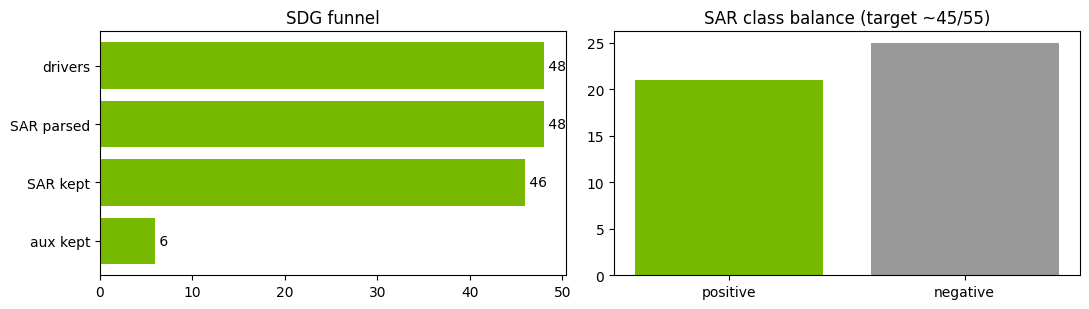

Curated SFT corpus -> data/final/sft_corpus.jsonl


In [17]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from notebook_env import ensure

ensure("matplotlib", ["matplotlib"], quiet=True)


import matplotlib.pyplot as plt

stages = [("drivers", len(drivers)), ("SAR parsed", int(drivers.pred_suspicious.notna().sum())),
          ("SAR kept", len(sar_records)), ("aux kept", len(aux_records))]
labels = [s for s, _ in stages]; counts = [n for _, n in stages]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].barh(range(len(labels)), counts, color="#76B900"); ax[0].set_yticks(range(len(labels)))
ax[0].set_yticklabels(labels); ax[0].invert_yaxis(); ax[0].set_title("SDG funnel")
for i, n in enumerate(counts): ax[0].text(n, i, f" {n}", va="center")
ax[1].bar(["positive", "negative"], [summary["sar_positive"], summary["sar_negative"]], color=["#76B900", "#999"])
ax[1].set_title(f"SAR class balance (target ~45/55)")
plt.tight_layout(); plt.show()
print("Curated SFT corpus -> data/final/sft_corpus.jsonl")
